# Aim
The purpose of this notebook is to show how to use JIT to tune a resnet model.

In [1]:
%%capture
%load_ext autoreload
%autoreload 2
%cd ../..
%pwd

In [2]:
from aitune.torch.jit.patcher import patch_for_jit_tuning
from aitune.torch.jit.patched_module import PatchedModule
from aitune.torch.jit.config import config
import torch

from notebooks.jit.jit_commons import visualize_latency

/home/pbazan/sources/ai-tune/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


[08/12/2025-09:23:35] [TRT] [W] Functionality provided through tensorrt.plugin module is experimental.


# Resnet

In [3]:
@patch_for_jit_tuning
def create_resnet():
    return torch.hub.load("pytorch/vision:v0.10.0", "resnet18",  weights="IMAGENET1K_V1").to("cuda")


In [4]:
resnet = create_resnet()

Using cache found in /home/pbazan/.cache/torch/hub/pytorch_vision_v0.10.0


In [5]:
config.min_samples = 4 # just to compare before and after tuning
config.dry_run = False
config.max_depth_level = 3
config.detect_graph_breaks = True

13:44:18.054 - INFO - ------------------------------------------------------------
13:44:18.054 - INFO - 🚀 Tuning graph `0` for module `ResNet 📊11.7M`:
13:44:18.054 - INFO -   number of parameters: 11.7M
13:44:18.055 - INFO -   number of layers: 10
13:44:18.055 - INFO -   precisions: torch.float32
13:44:18.056 - INFO -   graph_spec:
13:44:18.056 - INFO -     input_spec: ((input__0[dim0, 3, 224, 224] min_shape=[2, 3, 224, 224] max_shape=[16, 3, 224, 224] dtype=torch.float32,), {})
13:44:18.056 - INFO -     output_spec: output__0[dim0, 1000] min_shape=[2, 1000] max_shape=[16, 1000] dtype=torch.float32
13:44:18.056 - INFO -   num samples: 1
13:44:18.056 - INFO -   device: cuda
13:44:18.057 - INFO -   cache_dir: /home/pbazan/.cache/aitune.jit/31867e2c27a97ac395e3cdd8565478f33a8ea0d17bb0fc7f027524ead43116ba/0
13:44:18.057 - INFO -   strategy:
13:44:18.057 - INFO -     name: JIT Strategy
13:44:18.057 - INFO -     description: tailored for JIT tuning
13:44:18.057 - INFO -     backend: TensorR

[W] 'colored' module is not installed, will not use colors when logging. To enable colors, please install the 'colored' module: python3 -m pip install colored


13:44:20.126 - INFO - [I] Configuring with profiles:[
        Profile 0:
            {input__0 [min=(2, 3, 224, 224), opt=(16, 3, 224, 224), max=(16, 3, 224, 224)]}
    ]
13:44:20.127 - WARNING - [W] profileSharing0806 is on by default in TensorRT 10.0. This flag is deprecated and has no effect.
13:44:20.127 - Level 22 - [I] Building engine with configuration:
    Flags                  | [STRONGLY_TYPED]
    Engine Capability      | EngineCapability.STANDARD
    Memory Pools           | [WORKSPACE: 48632.00 MiB, TACTIC_DRAM: 48632.00 MiB, TACTIC_SHARED_MEMORY: 1024.00 MiB]
    Tactic Sources         | [EDGE_MASK_CONVOLUTIONS, JIT_CONVOLUTIONS]
    Profiling Verbosity    | ProfilingVerbosity.DETAILED
    Preview Features       | [PROFILE_SHARING_0806]
13:44:24.031 - Level 28 - [I] Finished engine building in 3.903 seconds
13:44:24.065 - INFO - [I] Saving engine to /home/pbazan/.cache/aitune.jit/31867e2c27a97ac395e3cdd8565478f33a8ea0d17bb0fc7f027524ead43116ba/0/TensorRTBackend/257a1412c

[08/11/2025-13:44:24] [TRT] [I] Loaded engine size: 74 MiB
[08/11/2025-13:44:24] [TRT] [I] [MemUsageChange] TensorRT-managed allocation in IExecutionContext creation: CPU +0, GPU +74, now: CPU 0, GPU 146 (MiB)


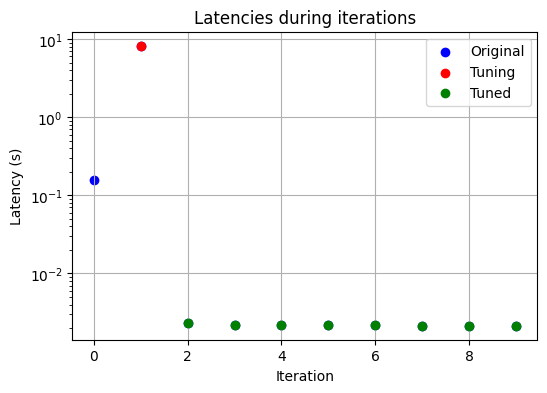

In [6]:
def batch():
    # we are calling two times with different batch sizes to recognize dynamic axes
    resnet(torch.randn(2, 3, 224, 224, device="cuda"))
    resnet(torch.randn(16, 3, 224, 224, device="cuda"))

# this will measure latency during calling batch function
visualize_latency(lambda: batch(), iterations=10)


Let's the see history of what happend under the hood.

In [7]:
PatchedModule.history

['New top module: ResNet 📊11.7M level=0🪜 state=init⏳ call_count=1',
 'New child module: Conv2d 📊9.4K level=1🪜 state=init⏳ call_count=1',
 'New child module: BatchNorm2d 📊128 level=1🪜 state=init⏳ call_count=1',
 'New child module: Sequential 📊148.0K level=1🪜 state=init⏳ call_count=1',
 'New child module: BasicBlock 📊74.0K level=2🪜 state=init⏳ call_count=1',
 'New child module: BasicBlock 📊74.0K level=2🪜 state=init⏳ call_count=1',
 'New child module: Sequential 📊525.6K level=1🪜 state=init⏳ call_count=1',
 'New child module: BasicBlock 📊230.1K level=2🪜 state=init⏳ call_count=1',
 'New child module: BasicBlock 📊295.4K level=2🪜 state=init⏳ call_count=1',
 'New child module: Sequential 📊2.1M level=1🪜 state=init⏳ call_count=1',
 'New child module: BasicBlock 📊919.0K level=2🪜 state=init⏳ call_count=1',
 'New child module: BasicBlock 📊1.2M level=2🪜 state=init⏳ call_count=1',
 'New child module: Sequential 📊8.4M level=1🪜 state=init⏳ call_count=1',
 'New child module: BasicBlock 📊3.7M level=2🪜 st

Let's see detected model architecture.

In [8]:
PatchedModule.print_hierarchy()

PatchedModule Hierarchy:
├─ ResNet 📊11.7M level=0🪜 state=tuned🎯 (TensorRTBackend) call_count=4
  ├─ Conv2d 📊9.4K level=1🪜 state=detached☑️ call_count=4
  ├─ BatchNorm2d 📊128 level=1🪜 state=detached☑️ call_count=4
  ├─ Sequential 📊148.0K level=1🪜 state=detached☑️ call_count=4
    ├─ BasicBlock 📊74.0K level=2🪜 state=detached☑️ call_count=4
    ├─ BasicBlock 📊74.0K level=2🪜 state=detached☑️ call_count=4
  ├─ Sequential 📊525.6K level=1🪜 state=detached☑️ call_count=4
    ├─ BasicBlock 📊230.1K level=2🪜 state=detached☑️ call_count=4
    ├─ BasicBlock 📊295.4K level=2🪜 state=detached☑️ call_count=4
  ├─ Sequential 📊2.1M level=1🪜 state=detached☑️ call_count=4
    ├─ BasicBlock 📊919.0K level=2🪜 state=detached☑️ call_count=4
    ├─ BasicBlock 📊1.2M level=2🪜 state=detached☑️ call_count=4
  ├─ Sequential 📊8.4M level=1🪜 state=detached☑️ call_count=4
    ├─ BasicBlock 📊3.7M level=2🪜 state=detached☑️ call_count=4
    ├─ BasicBlock 📊4.7M level=2🪜 state=detached☑️ call_count=4
  ├─ Linear 📊513.0K level=1

Let's call tuned module.

In [9]:
resnet(torch.randn(8, 3, 224, 224, device="cuda")).shape

torch.Size([8, 1000])

In [10]:
resnet(torch.randn(16, 3, 224, 224, device="cuda")).shape

torch.Size([16, 1000])

Currently the problem is when we provide too big batch size.

In [11]:
resnet(torch.randn(32, 3, 224, 224, device="cuda")).shape

[08/11/2025-13:44:24] [TRT] [E] IExecutionContext::setInputShape: Error Code 3: API Usage Error (Parameter check failed, condition: satisfyProfile. Set dimension [32,3,224,224] for tensor input__0 does not satisfy any optimization profiles. Valid range for profile 0: [2,3,224,224]..[16,3,224,224].)


torch.Size([16, 1000])